# Binary Classification

In [1]:
import sklearn
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
from pathlib import Path
import requests

if not Path('helper_functions.py').is_file():
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
    with open('helper_functions.py', 'wb') as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


## Create Dataset

In [2]:
# Create dataset
NUM_SAMPLES = 1000

X, y = make_circles(n_samples = NUM_SAMPLES,
                    noise=0.03,
                    random_state=42)

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

print(f'\nExamine the first 5 elements')
print('First 5 elements of X')
print(X[:5])
print('First 5 elements of y')
print(y[:5])


Shape of X: (1000, 2)
Shape of y: (1000,)

Examine the first 5 elements
First 5 elements of X
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 elements of y
[1 1 1 1 0]


## Dataset Visualization

Text(0.5, 1.0, 'Data Visualization')

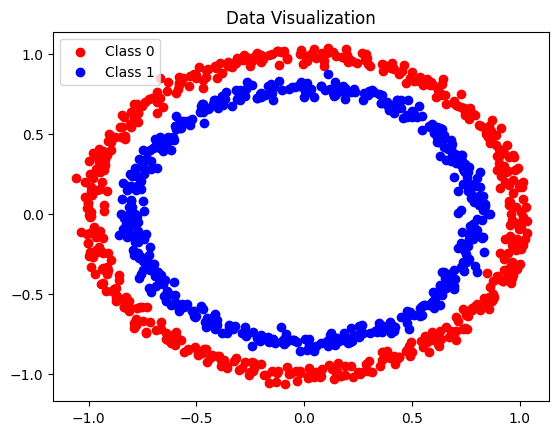

In [3]:
# Visualize dataset
plt.scatter(x=X[y==0, 0], y=X[y==0, 1], c='r', label='Class 0')
plt.scatter(x=X[y==1, 0], y=X[y==1, 1], c='b', label='Class 1')
plt.legend()
plt.title('Data Visualization')

## Dataset Split

In [4]:
# Datset Split

## Convert dataset into tensor
X = torch.tensor(X)
y = torch.tensor(y)

## Split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print('The result of the split')
print(f'Shape of X_train: ', X_train.shape)
print(f'Shape of X_test: ', X_test.shape)
print(f'Shape of y_train: ', y_train.shape)
print(f'Shape of y_test: ', y_test.shape)


The result of the split
Shape of X_train:  torch.Size([800, 2])
Shape of X_test:  torch.Size([200, 2])
Shape of y_train:  torch.Size([800])
Shape of y_test:  torch.Size([200])


## Build a model

In [5]:
# Building a model

## Device-agnostic
device = 'cuda' if torch.cuda.is_available() else 'cpu'


## Define the model
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=5),
            nn.ReLU(),
            nn.Linear(in_features=5, out_features=5),
            nn.ReLU(),
            nn.Linear(in_features=5, out_features=1)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x)

## Instnatiate model
model_0 = CircleModelV0().to(device)
print(model_0.state_dict())


OrderedDict({'linear_layers.0.weight': tensor([[-0.6631,  0.6933],
        [-0.1146, -0.1287],
        [-0.4781,  0.2203],
        [ 0.4555,  0.3655],
        [-0.6823,  0.1596]], device='cuda:0'), 'linear_layers.0.bias': tensor([-0.4028,  0.5965, -0.0508, -0.3562,  0.6677], device='cuda:0'), 'linear_layers.2.weight': tensor([[-0.1456, -0.2894,  0.4152,  0.1664,  0.0117],
        [ 0.0923,  0.2243, -0.1649, -0.2567,  0.4080],
        [-0.2961, -0.4324,  0.2505, -0.0555,  0.0480],
        [-0.4271,  0.1643, -0.3474, -0.0919, -0.3963],
        [ 0.2682, -0.1253, -0.4177, -0.0616, -0.2654]], device='cuda:0'), 'linear_layers.2.bias': tensor([-0.2767,  0.0847,  0.1856, -0.0447, -0.3191], device='cuda:0'), 'linear_layers.4.weight': tensor([[ 0.2342, -0.2367, -0.1874, -0.2613,  0.4463]], device='cuda:0'), 'linear_layers.4.bias': tensor([-0.2774], device='cuda:0')})


## Training

In [6]:
MANUAL_SEED = 42
torch.manual_seed(MANUAL_SEED)
torch.cuda.manual_seed(MANUAL_SEED)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=1e-1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return round((correct / len(y_true))*100, 2)

EPOCHS = 3000

X_train, X_test, y_train, y_test = X_train.to(device).to(torch.float32), X_test.to(device).to(torch.float32), y_train.to(device).to(torch.float32), y_test.to(device).to(torch.float32)


plt_epochs = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(EPOCHS):

    """ Training """
    model_0.train()
    y_logits = model_0(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    train_loss = loss_fn(y_logits, y_train)
    train_acc = accuracy_fn(y_train, y_preds)

    optimizer.zero_grad()
    train_loss.backward()

    optimizer.step()

    """ Evaluation / testing """
    model_0.eval()
    with torch.inference_mode():
        y_logits = model_0(X_test).squeeze()
        y_preds = torch.round(torch.sigmoid(y_logits))
        test_loss = loss_fn(y_logits, y_preds)
        test_acc = accuracy_fn(y_test, y_preds)
    
    """ Print Result """
    print('Current Epoch: ', epoch)
    print(f'Train Loss: {round(train_loss.item(),2)} | Train Accuracy: {round(train_acc, 2)}')
    print(f'Test Loss: {round(test_loss.item(),2)} | Test Accuracy: {round(test_acc, 2)}')

    """ Track values for plot """
    if epoch%100 == 0:
        plt_epochs.append(epoch)
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)

Current Epoch:  0
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.52 | Test Accuracy: 50.0
Current Epoch:  1
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.53 | Test Accuracy: 50.0
Current Epoch:  2
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.53 | Test Accuracy: 50.0
Current Epoch:  3
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.54 | Test Accuracy: 50.0
Current Epoch:  4
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.54 | Test Accuracy: 50.0
Current Epoch:  5
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.55 | Test Accuracy: 50.0
Current Epoch:  6
Train Loss: 0.71 | Train Accuracy: 50.0
Test Loss: 0.55 | Test Accuracy: 50.0
Current Epoch:  7
Train Loss: 0.7 | Train Accuracy: 50.0
Test Loss: 0.55 | Test Accuracy: 50.0
Current Epoch:  8
Train Loss: 0.7 | Train Accuracy: 50.0
Test Loss: 0.56 | Test Accuracy: 50.0
Current Epoch:  9
Train Loss: 0.7 | Train Accuracy: 50.0
Test Loss: 0.56 | Test Accuracy: 50.0
Current Epoch:  10
Train Loss: 0.7 | Train 

## Visualize Prediction

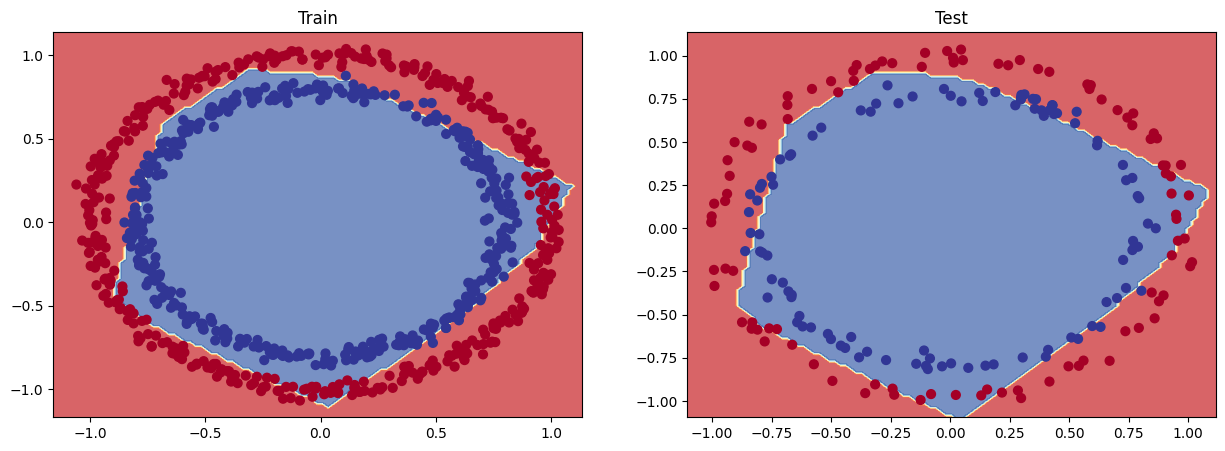

In [7]:

plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_0, X_test, y_test)